# Marker Isolation And Targeted Removal Analysis

Train GIN models at the configured depths on original inputs and on inputs where
all marker channels except selected lineage markers are zeroed, plus targeted
removal controls where selected channels are removed while all others remain.

The notebook evaluates:

- **orig/orig:** original training and original validation inputs
- **orig/reduced:** original training and marker-isolated validation inputs
- **reduced/reduced:** marker-isolated training and validation inputs

Validation MSE is summarized per organoid in the full organoid and in crypt,
neck, and villus regions. Figure bands show the standard error across organoids.
Only marker channels are zeroed, so input dimensionality and graph-level
features are retained.


**Setup**

In [1]:
import copy
import json
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "training_data"
sys.path.append(str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**

In [2]:
# Data and filtering: matched to ablation_analysis.ipynb
EXPERIMENT_GROUP = "lineage_removal"
DATASET_NAME = "after_cleanup"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_ANALYSIS = 0

USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True
SUBTRACT_CONSTANT_GLOBAL_BASELINE = False

TIMEPOINT_FILTER_MODE = "rest"  # "rest", "day3p5", or "all"
DAY3P5_TIMEPOINT = "day3p5"
FILL_MISSING_COMPLEXITY = True
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92 #0.96 # 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split mode
ANALYSIS_MODE = "folded"  # "single_split" for testing, "folded" for final results
VAL_FRAC = 0.2
N_FOLDS = 5
SPLIT_SEED = 42
FOLDS_TO_RUN = None  # None runs every split; e.g. [0] runs only the first fold

# Models and training
MODEL_DEPTHS = [0, 1, 2, 3, 4]
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 500
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}
SAVE_MODEL_CHECKPOINTS = False

# Region assignment from d_crypts_graph
DCRYPT_FIELD = "d_crypts_graph"
CRYPT_MAX = 0.75
NECK_MAX = 1.1
REGION_ORDER = ["full", "crypt", "neck", "villus"]

# Crypt-shape descriptors loaded from the segmentation files.
NECK_CIRCUMFERENCE_DISTANCE = 1.0
SIGNED_NECK_SHAPE_REFERENCE_MAX = CRYPT_MAX

# Previous marker-removal panels, retained here for reference.
# REMOVAL_SETS = [
#     {"key": "lgr5", "label": "LGR5", "markers": ["LGR5"]},
#     {"key": "lyso_agr2", "label": "Lysozyme + Agr2",
#      "markers": ["Lysozyme", "Agr2"]},
#     {"key": "sero_chroma", "label": "Serotonin + Chroma",
#      "markers": ["Serotonin", "Chroma"]},
#     {"key": "lyso_agr2_sero_chroma",
#      "label": "Lysozyme + Agr2 +\\nSerotonin + Chroma",
#      "markers": ["Lysozyme", "Agr2", "Serotonin", "Chroma"]},
#     {"key": "aldob", "label": "AldoB", "markers": ["AldoB"]},
#     {"key": "ki67", "label": "KI67", "markers": ["KI67"]},
#     {"key": "lgr5_ki67", "label": "LGR5 + KI67",
#      "markers": ["LGR5", "KI67"]},
#     {"key": "all_except_lgr5", "label": "Everything but LGR5",
#      "markers": "__ALL_EXCEPT_LGR5__"},
# ]

# Marker-panel isolation conditions. For keep_markers specs, every marker
# channel not listed is zeroed. Graph-level features remain available to the model.
ANALYSIS_VARIANT = "marker_panel_isolation"
REMOVAL_SETS = [
    {
        "key": "only_lgr5_aldob",
        "label": "LGR5 + AldoB only",
        "keep_markers": ["LGR5", "AldoB"],
    },
    {
        "key": "only_lyso_agr2_sero_chroma",
        "label": "Lysozyme + Agr2\n+ Serotonin + Chroma only",
        "keep_markers": ["Lysozyme", "Agr2", "Serotonin", "Chroma"],
    },
    {
        "key": "only_lgr5_ki67_lyso_agr2_sero_chroma",
        "label": "LGR5 + KI67\n+ Lysozyme/Agr2\n+ Sero/Chroma only",
        "keep_markers": ["LGR5", "KI67", "Lysozyme", "Agr2", "Serotonin", "Chroma"],
    },
    {
        "key": "only_aldob_ki67",
        "label": "AldoB + KI67 only",
        "keep_markers": ["AldoB", "KI67"],
    },
    {
        "key": "only_aldob_sero_chroma",
        "label": "AldoB + Serotonin\n+ Chroma only",
        "keep_markers": ["AldoB", "Serotonin", "Chroma"],
    },
    {
        "key": "only_aldob_lyso_agr2",
        "label": "AldoB + Lysozyme\n+ Agr2 only",
        "keep_markers": ["AldoB", "Lysozyme", "Agr2"],
    },
]

# Output
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = (
    f"{ANALYSIS_VARIANT}_{ANALYSIS_MODE}_"
    f"depths-{'-'.join(map(str, MODEL_DEPTHS))}_{RUN_TIMESTAMP}"
)
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
MODELS_DIR = SAVE_DIR / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
if SAVE_MODEL_CHECKPOINTS:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)


def set_all_seeds(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


set_all_seeds(SPLIT_SEED)

**Utilities**

In [3]:
def save_figure(fig, name, *, dpi=300):
    for suffix in ("pdf", "png"):
        fig.savefig(FIGURES_DIR / f"{name}.{suffix}", dpi=dpi, bbox_inches="tight")


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, (torch.dtype, np.dtype)):
        return str(obj)
    return obj


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D values, got shape {arr.shape}.")


def marker_index(name, marker_names_in):
    names = list(marker_names_in)
    if name in names:
        return names.index(name)
    lower = {str(marker).lower(): i for i, marker in enumerate(names)}
    key = str(name).lower()
    if key not in lower:
        raise ValueError(f"Marker {name!r} not found in {names}.")
    return lower[key]


def resolve_removal_sets(removal_sets, marker_names_in):
    marker_names_in = list(marker_names_in)
    resolved = []
    for spec in removal_sets:
        out = dict(spec)
        if "keep_markers" in spec:
            kept_indices = {
                marker_index(marker, marker_names_in)
                for marker in spec["keep_markers"]
            }
            out["keep_markers"] = [
                marker_names_in[index] for index in sorted(kept_indices)
            ]
            out["markers"] = [
                marker
                for index, marker in enumerate(marker_names_in)
                if index not in kept_indices
            ]
        elif spec["markers"] == "__ALL_EXCEPT_LGR5__":
            lgr5_idx = marker_index("LGR5", marker_names_in)
            out["keep_markers"] = [marker_names_in[lgr5_idx]]
            out["markers"] = [
                marker
                for index, marker in enumerate(marker_names_in)
                if index != lgr5_idx
            ]
        else:
            out["markers"] = list(spec["markers"])
            out["keep_markers"] = [
                marker
                for marker in marker_names_in
                if marker_index(marker, marker_names_in)
                not in {
                    marker_index(removed, marker_names_in)
                    for removed in out["markers"]
                }
            ]
        for marker in out["markers"]:
            marker_index(marker, marker_names_in)
        resolved.append(out)
    return resolved


def zero_marker_channels(graphs_in, markers_to_remove, marker_names_in):
    marker_indices = [
        marker_index(marker, marker_names_in) for marker in markers_to_remove
    ]
    graphs_out = [copy.deepcopy(graph) for graph in graphs_in]
    counts = {marker: 0 for marker in markers_to_remove}
    for graph in graphs_out:
        graph.x = graph.x.clone()
        for marker, marker_idx in zip(markers_to_remove, marker_indices):
            counts[marker] += int((graph.x[:, marker_idx] > 0.5).sum().item())
            graph.x[:, marker_idx] = 0
    return graphs_out, counts


def _nanmin_or_nan(values, axis):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    filled = np.where(finite, arr, np.inf)
    out = np.asarray(np.min(filled, axis=axis), dtype=float)
    out[~np.any(finite, axis=axis)] = np.nan
    return out


def dcrypt_matrix(raw, n_nodes):
    """Return d_crypt values as (n_crypts, n_nodes)."""
    arr = np.asarray(raw, dtype=float)
    if arr.size == 0:
        return np.empty((0, n_nodes), dtype=float)
    if arr.ndim == 0:
        return np.full((1, n_nodes), float(arr), dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] == n_nodes:
            return arr.reshape(1, n_nodes).astype(float)
        if arr.shape[0] == 1:
            return np.full((1, n_nodes), float(arr[0]), dtype=float)
        raise ValueError(
            f"Cannot align dcrypt length {arr.shape[0]} to {n_nodes} nodes."
        )
    if arr.ndim >= 2:
        if arr.shape[-1] == n_nodes:
            return arr.reshape(-1, n_nodes).astype(float)
        if arr.shape[0] == n_nodes:
            return np.moveaxis(arr, 0, -1).reshape(-1, n_nodes).astype(float)
        if n_nodes in arr.shape:
            node_axis = list(arr.shape).index(n_nodes)
            return np.moveaxis(arr, node_axis, -1).reshape(-1, n_nodes).astype(float)
    raise ValueError(
        f"Cannot align dcrypt array with shape {arr.shape} to {n_nodes} nodes."
    )


def min_node_dcrypt(raw, n_nodes):
    matrix = dcrypt_matrix(raw, n_nodes)
    if matrix.shape[0] == 0:
        return np.full(n_nodes, np.nan, dtype=float)
    return _nanmin_or_nan(matrix, axis=0)


_CRYPT_SHAPE_CACHE = {}


def _safe_float_array(value, *, ndim=None):
    arr = np.asarray(value, dtype=float)
    if ndim is not None and arr.ndim != ndim:
        return np.asarray([], dtype=float)
    return arr


def signed_neck_shape_from_profile(
    d_discretized,
    circumference_crypts,
    *,
    neck_distance=NECK_CIRCUMFERENCE_DISTANCE,
    reference_max=SIGNED_NECK_SHAPE_REFERENCE_MAX,
):
    s = _safe_float_array(d_discretized, ndim=1)
    C = np.asarray(circumference_crypts, dtype=float)
    if s.size == 0 or C.size == 0:
        return np.asarray([], dtype=float)
    if C.ndim == 1:
        C = C.reshape(1, -1)
    if C.ndim != 2 or C.shape[1] != s.size:
        return np.full(C.shape[0] if C.ndim >= 1 else 0, np.nan, dtype=float)

    out = np.full(C.shape[0], np.nan, dtype=float)
    for crypt_idx, profile in enumerate(C):
        finite = np.isfinite(s) & np.isfinite(profile)
        ref_mask = finite & (s < float(reference_max))
        if not np.any(ref_mask):
            continue
        c_ref = float(np.nanmax(profile[ref_mask]))
        if not (np.isfinite(c_ref) and c_ref > 0):
            continue

        order = np.argsort(s[finite])
        s_finite = s[finite][order]
        c_finite = profile[finite][order]
        if s_finite.size == 0:
            continue
        c_neck = float(np.interp(
            float(neck_distance),
            s_finite,
            c_finite,
            left=np.nan,
            right=np.nan,
        ))
        if not np.isfinite(c_neck):
            nearest = int(np.nanargmin(np.abs(s_finite - float(neck_distance))))
            c_neck = float(c_finite[nearest])
        if np.isfinite(c_neck):
            out[crypt_idx] = c_neck / c_ref - 1.0
    return out


def load_crypt_shape_metadata(segmentation_path):
    if segmentation_path is None or pd.isna(segmentation_path):
        return {
            "crypt_constrictions": np.asarray([], dtype=float),
            "signed_neck_shape": np.asarray([], dtype=float),
        }
    key = str(Path(segmentation_path).expanduser())
    if key in _CRYPT_SHAPE_CACHE:
        return _CRYPT_SHAPE_CACHE[key]

    path = Path(key)
    if not path.exists():
        out = {
            "crypt_constrictions": np.asarray([], dtype=float),
            "signed_neck_shape": np.asarray([], dtype=float),
        }
        _CRYPT_SHAPE_CACHE[key] = out
        return out

    try:
        with np.load(path, allow_pickle=True) as seg:
            constrictions = _safe_float_array(
                seg["crypt_constrictions"] if "crypt_constrictions" in seg else [],
                ndim=1,
            )
            signed_shape = signed_neck_shape_from_profile(
                seg["d_discretized"] if "d_discretized" in seg else [],
                seg["circumference_crypts"] if "circumference_crypts" in seg else [],
            )
    except Exception as exc:
        print(f"Warning: failed loading crypt shape metadata from {path}: {exc}")
        constrictions = np.asarray([], dtype=float)
        signed_shape = np.asarray([], dtype=float)

    out = {
        "crypt_constrictions": constrictions,
        "signed_neck_shape": signed_shape,
    }
    _CRYPT_SHAPE_CACHE[key] = out
    return out


def nearest_crypt_shape_features(graph, *, meta_lookup):
    from src.data.metadata import get_graph_metadata

    n_nodes = int(graph.x.shape[0])
    metadata = get_graph_metadata(
        graph, meta_lookup=meta_lookup, strict=False, default={}
    )
    matrix = dcrypt_matrix(
        metadata.get(DCRYPT_FIELD, np.asarray([], dtype=float)), n_nodes
    )
    nearest_crypt = np.full(n_nodes, -1, dtype=int)
    nearest_dcrypt = np.full(n_nodes, np.nan, dtype=float)
    if matrix.shape[0] > 0:
        finite = np.isfinite(matrix)
        has_crypt = np.any(finite, axis=0)
        filled = np.where(finite, matrix, np.inf)
        nearest = np.argmin(filled, axis=0)
        nearest_crypt[has_crypt] = nearest[has_crypt]
        nearest_dcrypt[has_crypt] = filled[nearest[has_crypt], np.where(has_crypt)[0]]

    shape = load_crypt_shape_metadata(metadata.get("segmentation_path"))
    constrictions = np.asarray(shape["crypt_constrictions"], dtype=float)
    signed_shape = np.asarray(shape["signed_neck_shape"], dtype=float)

    node_constriction = np.full(n_nodes, np.nan, dtype=float)
    node_signed_shape = np.full(n_nodes, np.nan, dtype=float)
    valid_nearest = nearest_crypt >= 0
    if constrictions.size:
        idx = valid_nearest & (nearest_crypt < constrictions.size)
        node_constriction[idx] = constrictions[nearest_crypt[idx]]
    if signed_shape.size:
        idx = valid_nearest & (nearest_crypt < signed_shape.size)
        node_signed_shape[idx] = signed_shape[nearest_crypt[idx]]

    return {
        "nearest_crypt_index": nearest_crypt,
        "nearest_dcrypt": nearest_dcrypt,
        "crypt_constriction": node_constriction,
        "signed_neck_shape": node_signed_shape,
    }


def summarize_region_crypt_shape(shape_features, mask):
    mask = np.asarray(mask, dtype=bool)
    nearest = np.asarray(shape_features["nearest_crypt_index"])[mask]
    constriction = np.asarray(shape_features["crypt_constriction"], dtype=float)[mask]
    signed_shape = np.asarray(shape_features["signed_neck_shape"], dtype=float)[mask]

    valid_nearest = nearest >= 0
    valid_constriction = np.isfinite(constriction)
    valid_signed = np.isfinite(signed_shape)

    def finite_stats(values):
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            return np.nan, np.nan, np.nan
        std = float(np.std(values, ddof=1)) if values.size > 1 else 0.0
        return float(np.mean(values)), float(std), float(np.median(values))

    mean_constriction, std_constriction, median_constriction = finite_stats(constriction)
    mean_signed, std_signed, median_signed = finite_stats(signed_shape)
    return {
        "n_nodes_with_nearest_crypt": int(valid_nearest.sum()),
        "n_unique_nearest_crypts": int(len(np.unique(nearest[valid_nearest]))),
        "n_nodes_with_crypt_constriction": int(valid_constriction.sum()),
        "mean_crypt_constriction": mean_constriction,
        "std_crypt_constriction": std_constriction,
        "median_crypt_constriction": median_constriction,
        "n_nodes_with_signed_neck_shape": int(valid_signed.sum()),
        "mean_signed_neck_shape": mean_signed,
        "std_signed_neck_shape": std_signed,
        "median_signed_neck_shape": median_signed,
    }


def crypt_neck_shape_assignment_rows(graphs_in, *, meta_lookup, fold):
    from src.data.metadata import get_graph_metadata

    rows = []
    for graph in graphs_in:
        masks = region_masks_for_graph(graph, meta_lookup=meta_lookup)
        shape = nearest_crypt_shape_features(graph, meta_lookup=meta_lookup)
        key = graph_metadata_key(graph, meta_lookup=meta_lookup)
        organoid_id = " | ".join(map(str, key))
        metadata = get_graph_metadata(
            graph, meta_lookup=meta_lookup, strict=False, default={}
        )
        n_nodes = int(graph.x.shape[0])
        original_ids = metadata.get("new_to_old_index")
        if original_ids is None:
            original_ids = metadata.get("kept_node_ids")
        if original_ids is None or len(original_ids) != n_nodes:
            original_ids = list(range(n_nodes))

        for region in ("crypt", "neck"):
            region_mask = masks[region]
            for node_id in np.where(region_mask)[0]:
                node_id = int(node_id)
                rows.append({
                    "fold": int(fold),
                    "organoid_id": organoid_id,
                    "dataset": metadata.get("dataset"),
                    "timepoint": metadata.get("timepoint"),
                    "label_uid": metadata.get("label_uid"),
                    "node_id": node_id,
                    "node_original_id": int(original_ids[node_id]),
                    "region": region,
                    "nearest_crypt_index": int(shape["nearest_crypt_index"][node_id]),
                    "nearest_dcrypt": float(shape["nearest_dcrypt"][node_id]),
                    "crypt_constriction": float(shape["crypt_constriction"][node_id]),
                    "signed_neck_shape": float(shape["signed_neck_shape"][node_id]),
                })
    return rows


def region_masks_for_graph(graph, *, meta_lookup):
    from src.data.metadata import get_graph_metadata

    n_nodes = int(graph.x.shape[0])
    metadata = get_graph_metadata(
        graph, meta_lookup=meta_lookup, strict=False, default={}
    )
    dcrypt = min_node_dcrypt(
        metadata.get(DCRYPT_FIELD, np.asarray([], dtype=float)), n_nodes
    )
    finite = np.isfinite(dcrypt)
    return {
        "full": np.ones(n_nodes, dtype=bool),
        "crypt": finite & (dcrypt < CRYPT_MAX),
        "neck": finite & (dcrypt >= CRYPT_MAX) & (dcrypt <= NECK_MAX),
        "villus": (~finite) | (dcrypt > NECK_MAX),
    }


## 1. Load And Filter Data

In [4]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_metadata,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
metadata = load_aux_metadata_for_dir(str(data_dir))
attach_metadata_to_graphs(graphs, metadata, exclude_keys=None)
graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    marker_names = [f"marker_{i}" for i in range(int(graphs[0].x.size(1)))]
print(f"Loaded {len(graphs)} organoids and {len(marker_names)} markers.")

if TIMEPOINT_FILTER_MODE == "rest":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        drop_values={DAY3P5_TIMEPOINT},
        missing="keep",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE == "day3p5":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        keep_values={DAY3P5_TIMEPOINT},
        missing="drop",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE not in (None, "all"):
    raise ValueError(
        'TIMEPOINT_FILTER_MODE must be "rest", "day3p5", or "all".'
    )

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)
else:
    blacklist = set()

if FILL_MISSING_COMPLEXITY:
    graphs = fill_missing_metadata_for_group(
        graphs,
        field="complexity",
        fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
        dataset=MISSING_COMPLEXITY_GROUP["dataset"],
        timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
    )

graphs, spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)
spherical = filter_graphs_by_marker_diversity(
    spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)
# graphs = filter_graphs_by_numeric_metadata(
#     graphs,
#     key="complexity",
#     min_value=COMPLEXITY_MIN,
#     allow_missing=False,
#     inplace=False,
#     print_summary=True,
# )
if INTERPOLATE_TARGET_OUTLIERS:
    graphs, target_outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    target_outlier_info = None

REMOVAL_SETS_RESOLVED = resolve_removal_sets(REMOVAL_SETS, marker_names)
print(f"After filtering: {len(graphs)} organoids.")
display(pd.DataFrame(REMOVAL_SETS_RESOLVED))

Loaded 1500 graphs; skipped 0.
Loaded 1500 organoids and 7 markers.
filter_graphs_by_metadata(key='timepoint'): kept 1210 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    290    0.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
20251201         day4p5              278    278    1.000
filter_graphs_by_blacklist(n_keys=17): kept 1193 / 1210 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                330    342    0.965
20250929         day4p5              112    113    0.991
20250929         day4p5-more         475    477    0.996
20251201         day4p5              276    278    0.993
filter_graphs_by_sphericity(max_sphericity=0.92): kept

,key,label,keep_markers,markers
0,only_lgr5_aldob,LGR5 + AldoB only,"[AldoB, LGR5]","[Agr2, Chroma, KI67, Lysozyme, Serotonin]"
1,only_lyso_agr2_sero_chroma,Lysozyme + Agr2\n+ Serotonin + Chroma only,"[Agr2, Chroma, Lysozyme, Serotonin]","[AldoB, KI67, LGR5]"
2,only_lgr5_ki67_lyso_agr2_sero_chroma,LGR5 + KI67\n+ Lysozyme/Agr2\n+ Sero/Chroma only,"[Agr2, Chroma, KI67, LGR5, Lysozyme, Serotonin]",[AldoB]
3,only_aldob_ki67,AldoB + KI67 only,"[AldoB, KI67]","[Agr2, Chroma, LGR5, Lysozyme, Serotonin]"
4,only_aldob_sero_chroma,AldoB + Serotonin\n+ Chroma only,"[AldoB, Chroma, Serotonin]","[Agr2, KI67, LGR5, Lysozyme]"
5,only_aldob_lyso_agr2,AldoB + Lysozyme\n+ Agr2 only,"[Agr2, AldoB, Lysozyme]","[Chroma, KI67, LGR5, Serotonin]"


## 2. Organoid Splits

In [5]:
from src.data.splits import graph_metadata_key, train_val_split_graphs


def make_organoid_kfolds(graphs_in, *, n_folds=5, seed=0):
    if len(graphs_in) < n_folds:
        raise ValueError(f"Need at least {n_folds} graphs, got {len(graphs_in)}.")
    keys = [graph_metadata_key(graph) for graph in graphs_in]
    if len(set(keys)) != len(keys):
        raise ValueError("Expected unique organoid metadata keys.")

    rng = np.random.default_rng(seed)
    indices = np.arange(len(graphs_in), dtype=int)
    rng.shuffle(indices)
    val_folds = np.array_split(indices, n_folds)
    splits_out = []
    for fold_id, val_indices in enumerate(val_folds):
        val_indices = np.asarray(val_indices, dtype=int)
        val_set = set(val_indices.tolist())
        train_indices = np.asarray(
            [i for i in range(len(graphs_in)) if i not in val_set],
            dtype=int,
        )
        splits_out.append({
            "fold": fold_id,
            "train_indices": train_indices,
            "val_indices": val_indices,
            "train_keys": [keys[int(i)] for i in train_indices],
            "val_keys": [keys[int(i)] for i in val_indices],
        })
    return splits_out


def make_analysis_splits(graphs_in):
    if ANALYSIS_MODE == "folded":
        return make_organoid_kfolds(
            graphs_in, n_folds=N_FOLDS, seed=SPLIT_SEED
        )
    if ANALYSIS_MODE != "single_split":
        raise ValueError(
            'ANALYSIS_MODE must be "single_split" or "folded".'
        )
    _, _, split_info = train_val_split_graphs(
        graphs_in,
        val_frac=VAL_FRAC,
        seed=SPLIT_SEED,
        key_fn=graph_metadata_key,
        inplace=False,
    )
    return [{
        "fold": 0,
        "train_indices": np.asarray(split_info["train_indices"], dtype=int),
        "val_indices": np.asarray(split_info["val_indices"], dtype=int),
        "train_keys": split_info["train_keys"],
        "val_keys": split_info["val_keys"],
    }]


splits = make_analysis_splits(graphs)
if FOLDS_TO_RUN is not None:
    selected_folds = {int(fold) for fold in FOLDS_TO_RUN}
    splits = [split for split in splits if int(split["fold"]) in selected_folds]
    if not splits:
        raise ValueError("FOLDS_TO_RUN did not select any available folds.")

split_summary_df = pd.DataFrame([{
    "fold": int(split["fold"]),
    "n_train_graphs": len(split["train_indices"]),
    "n_val_graphs": len(split["val_indices"]),
} for split in splits])
split_summary_df.to_csv(TABLES_DIR / "split_summary.csv", index=False)
display(split_summary_df)

,fold,n_train_graphs,n_val_graphs
0,0,648,163
1,1,649,162
2,2,649,162
3,3,649,162
4,4,649,162


## 3. Fold Preparation And Models

In [6]:
from src.data.metadata import (
    add_log_metadata_features,
    infer_global_dim,
    promote_metadata_to_graph_tensors,
    snapshot_graph_metadata,
    strip_graph_metadata,
)
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)
from src.models.baseline import GlobalFeatureMLP
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

FIELD_SPECS = [{
    "meta_keys": [
        "log_surface_area",
        "log_volume",
        "log_volume_over_area",
        "log_num_cells",
    ],
    "attr_name": "global_feat",
    "kind": "graph_vector",
    "dtype": torch.float32,
}]


def prepare_fold_graphs(train_graphs, val_graphs):
    g_train = copy.deepcopy(train_graphs)
    g_val = copy.deepcopy(val_graphs)

    if USE_GLOBAL_FEATURES:
        g_train = promote_metadata_to_graph_tensors(
            add_log_metadata_features(g_train, inplace=False),
            FIELD_SPECS,
            inplace=False,
        )
        g_val = promote_metadata_to_graph_tensors(
            add_log_metadata_features(g_val, inplace=False),
            FIELD_SPECS,
            inplace=False,
        )

    train_meta_lookup = snapshot_graph_metadata(g_train)
    val_meta_lookup = snapshot_graph_metadata(g_val)
    g_train = strip_graph_metadata(g_train, inplace=False)
    g_val = strip_graph_metadata(g_val, inplace=False)

    if USE_GLOBAL_FEATURES:
        standardize_graph_global_features(
            g_train, g_val, attr_name="global_feat", robust=False
        )

    if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
        target_transform = ChainedTargetTransform([
            GlobalBaselineResidualTransform(num_workers=NUM_WORKERS),
            AsinhStandardizeTransform(robust=True),
        ])
    else:
        target_transform = AsinhStandardizeTransform(robust=True)
    target_transform.fit(g_train)
    target_transform.transform_graphs(g_train, in_place=True)
    target_transform.transform_graphs(g_val, in_place=True)

    return {
        "g_train": g_train,
        "g_val": g_val,
        "train_meta_lookup": train_meta_lookup,
        "val_meta_lookup": val_meta_lookup,
        "target_transform": target_transform,
    }


def infer_target_dim(graphs_in):
    y = graphs_in[0].y
    return 1 if y.ndim == 1 else int(y.shape[1])


def make_gin_model(graphs_in, depth):
    return GINCurvature(
        n_markers=int(graphs_in[0].x.size(1)),
        global_dim=infer_global_dim(graphs_in),
        hidden_dim=HIDDEN_DIM,
        num_layers=int(depth),
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
        target_dim=infer_target_dim(graphs_in),
    )


def make_global_baseline(graphs_in):
    return GlobalFeatureMLP(
        global_dim=infer_global_dim(graphs_in),
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        target_dim=infer_target_dim(graphs_in),
    )


def make_train_config():
    return TrainConfig(
        lr=LR,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        num_workers=NUM_WORKERS,
        aux_losses=[WeightedLossTerm(
            name="edge",
            fn=edge_loss_term,
            weight=EDGE_LOSS_WEIGHT,
            params=EDGE_LOSS_PARAMS,
        )],
    )


cfg = make_train_config()
device = cfg.device
print("device =", device)

device = cuda


## 4. Organoid-Level Regional Evaluation

In [7]:
from src.inference.predict import predict_targets


def predict_graphwise(graphs_in, model, target_transform):
    y_true, y_pred, _ = predict_targets(
        graphs_in,
        model,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        target_transform=target_transform,
    )
    y_true = select_target_column(y_true, TARGET_INDEX_FOR_ANALYSIS)
    y_pred = select_target_column(y_pred, TARGET_INDEX_FOR_ANALYSIS)

    output = []
    offset = 0
    for graph in graphs_in:
        n_nodes = int(graph.x.shape[0])
        output.append({
            "y_true": y_true[offset:offset + n_nodes],
            "y_pred": y_pred[offset:offset + n_nodes],
        })
        offset += n_nodes
    if offset != len(y_true):
        raise RuntimeError("Prediction output did not align with graph sizes.")
    return output


def regional_mse_rows(
    graphs_in,
    predictions,
    *,
    meta_lookup,
    fold,
    removal_key,
    removal_label,
    train_eval_key,
    train_eval_label,
    depth=None,
):
    rows = []
    for graph, pred in zip(graphs_in, predictions):
        masks = region_masks_for_graph(graph, meta_lookup=meta_lookup)
        shape_features = nearest_crypt_shape_features(
            graph, meta_lookup=meta_lookup
        )
        key = graph_metadata_key(graph, meta_lookup=meta_lookup)
        organoid_id = " | ".join(map(str, key))
        squared_error = np.square(pred["y_pred"] - pred["y_true"])
        for region in REGION_ORDER:
            mask = masks[region]
            if not np.any(mask):
                continue
            row = {
                "fold": int(fold),
                "organoid_id": organoid_id,
                "removal_key": removal_key,
                "removal_label": removal_label,
                "train_eval_key": train_eval_key,
                "train_eval_label": train_eval_label,
                "depth": np.nan if depth is None else int(depth),
                "region": region,
                "n_nodes": int(mask.sum()),
                "mse": float(np.mean(squared_error[mask])),
            }
            if region in ("crypt", "neck"):
                row.update(summarize_region_crypt_shape(shape_features, mask))
            rows.append(row)
    return rows

def summarize_organoid_mse(rows_df, group_columns):
    def summarize(group):
        values = group["mse"].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        n = len(values)
        std = float(np.std(values, ddof=1)) if n > 1 else 0.0
        return pd.Series({
            "mean_mse": float(np.mean(values)) if n else np.nan,
            "std_mse": std if n else np.nan,
            "sem_mse": std / np.sqrt(n) if n else np.nan,
            "n_organoids": int(n),
            "n_nodes": int(group["n_nodes"].sum()),
        })

    return (
        rows_df.groupby(group_columns, dropna=False, sort=False)
        .apply(summarize, include_groups=False)
        .reset_index()
    )

## 5. Train And Evaluate

In folded mode the global-feature baseline is trained once **per fold**, because each fold has a different training set. Within a fold it is reused for every removal panel. Results are written incrementally after each completed model.

In [8]:
organoid_mse_rows = []
baseline_mse_rows = []
training_rows = []
zero_count_rows = []
crypt_shape_rows = []


def persist_partial_results():
    pd.DataFrame(organoid_mse_rows).to_csv(
        TABLES_DIR / "organoid_level_mse_partial.csv", index=False
    )
    pd.DataFrame(baseline_mse_rows).to_csv(
        TABLES_DIR / "global_baseline_organoid_mse_partial.csv", index=False
    )
    pd.DataFrame(training_rows).to_csv(
        TABLES_DIR / "training_summary_partial.csv", index=False
    )
    pd.DataFrame(zero_count_rows).to_csv(
        TABLES_DIR / "marker_zero_counts_partial.csv", index=False
    )
    pd.DataFrame(crypt_shape_rows).to_csv(
        TABLES_DIR / "crypt_neck_shape_assignments_partial.csv", index=False
    )


for split in splits:
    fold = int(split["fold"])
    fold_seed = SPLIT_SEED + 10000 * fold
    print(f"\n{'=' * 72}\nFold {fold + 1}/{len(splits)}\n{'=' * 72}")

    raw_train = [graphs[int(i)] for i in split["train_indices"]]
    raw_val = [graphs[int(i)] for i in split["val_indices"]]
    pack = prepare_fold_graphs(raw_train, raw_val)
    g_train = pack["g_train"]
    g_val = pack["g_val"]
    val_meta_lookup = pack["val_meta_lookup"]
    target_transform = pack["target_transform"]

    crypt_shape_rows.extend(crypt_neck_shape_assignment_rows(
        g_val, meta_lookup=val_meta_lookup, fold=fold
    ))

    # One marker-blind baseline per fold.
    set_all_seeds(fold_seed + 9000)
    print(f"Training global baseline | fold={fold}")
    baseline_model = make_global_baseline(g_train)
    baseline_model, baseline_metrics, baseline_history = train(
        baseline_model, g_train, g_val, cfg
    )
    baseline_predictions = predict_graphwise(
        g_val, baseline_model, target_transform
    )
    baseline_mse_rows.extend(regional_mse_rows(
        g_val,
        baseline_predictions,
        meta_lookup=val_meta_lookup,
        fold=fold,
        removal_key="global_baseline",
        removal_label="Global baseline",
        train_eval_key="global_baseline",
        train_eval_label="Global baseline",
        depth=None,
    ))
    training_rows.append({
        "fold": fold,
        "removal_key": "global_baseline",
        "train_eval_key": "global_baseline",
        "depth": np.nan,
        "val_mae_transformed": float(baseline_metrics["val_mae"]),
        "epochs_trained": len(baseline_history["val_mae"]),
    })
    if SAVE_MODEL_CHECKPOINTS:
        torch.save(
            baseline_model.state_dict(),
            MODELS_DIR / f"fold{fold}_global_baseline.pt",
        )
    del baseline_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Original models are trained once per depth and reused for all eval-only reductions.
    original_models = {}
    for depth in MODEL_DEPTHS:
        set_all_seeds(fold_seed + int(depth))
        print(f"Training original GIN | fold={fold} | depth={depth}")
        model = make_gin_model(g_train, depth)
        model, metrics, history = train(model, g_train, g_val, cfg)
        original_models[int(depth)] = model
        training_rows.append({
            "fold": fold,
            "removal_key": "original",
            "train_eval_key": "orig_orig",
            "depth": int(depth),
            "val_mae_transformed": float(metrics["val_mae"]),
            "epochs_trained": len(history["val_mae"]),
        })
        original_predictions = predict_graphwise(
            g_val, model, target_transform
        )
        for spec in REMOVAL_SETS_RESOLVED:
            organoid_mse_rows.extend(regional_mse_rows(
                g_val,
                original_predictions,
                meta_lookup=val_meta_lookup,
                fold=fold,
                removal_key=spec["key"],
                removal_label=spec["label"],
                train_eval_key="orig_orig",
                train_eval_label="orig/orig",
                depth=depth,
            ))
        if SAVE_MODEL_CHECKPOINTS:
            torch.save(
                model.state_dict(),
                MODELS_DIR / f"fold{fold}_original_depth{depth}.pt",
            )
        persist_partial_results()

    for removal_idx, spec in enumerate(REMOVAL_SETS_RESOLVED):
        removal_key = spec["key"]
        removal_label = spec["label"]
        markers = spec["markers"]
        print(f"\nRemoval: {removal_label} -> {markers}")
        g_train_reduced, train_counts = zero_marker_channels(
            g_train, markers, marker_names
        )
        g_val_reduced, val_counts = zero_marker_channels(
            g_val, markers, marker_names
        )
        for marker in markers:
            zero_count_rows.append({
                "fold": fold,
                "removal_key": removal_key,
                "removal_label": removal_label,
                "marker": marker,
                "train_positive_values_zeroed": int(train_counts[marker]),
                "val_positive_values_zeroed": int(val_counts[marker]),
            })

        for depth in MODEL_DEPTHS:
            depth = int(depth)
            # Original model evaluated on reduced validation inputs.
            eval_only_predictions = predict_graphwise(
                g_val_reduced, original_models[depth], target_transform
            )
            organoid_mse_rows.extend(regional_mse_rows(
                g_val_reduced,
                eval_only_predictions,
                meta_lookup=val_meta_lookup,
                fold=fold,
                removal_key=removal_key,
                removal_label=removal_label,
                train_eval_key="orig_reduced",
                train_eval_label="orig/reduced",
                depth=depth,
            ))

            # Reduced model trained and evaluated with the same zeroed channels.
            model_seed = fold_seed + 100 * (removal_idx + 1) + depth
            set_all_seeds(model_seed)
            print(
                f"Training reduced GIN | fold={fold} | "
                f"removal={removal_key} | depth={depth}"
            )
            reduced_model = make_gin_model(g_train_reduced, depth)
            reduced_model, metrics, history = train(
                reduced_model, g_train_reduced, g_val_reduced, cfg
            )
            training_rows.append({
                "fold": fold,
                "removal_key": removal_key,
                "train_eval_key": "reduced_reduced",
                "depth": depth,
                "val_mae_transformed": float(metrics["val_mae"]),
                "epochs_trained": len(history["val_mae"]),
            })
            reduced_predictions = predict_graphwise(
                g_val_reduced, reduced_model, target_transform
            )
            organoid_mse_rows.extend(regional_mse_rows(
                g_val_reduced,
                reduced_predictions,
                meta_lookup=val_meta_lookup,
                fold=fold,
                removal_key=removal_key,
                removal_label=removal_label,
                train_eval_key="reduced_reduced",
                train_eval_label="reduced/reduced",
                depth=depth,
            ))
            if SAVE_MODEL_CHECKPOINTS:
                torch.save(
                    reduced_model.state_dict(),
                    MODELS_DIR / (
                        f"fold{fold}_{removal_key}_depth{depth}.pt"
                    ),
                )
            del reduced_model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            persist_partial_results()

        del g_train_reduced, g_val_reduced

    del original_models
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Finished all requested folds.")


Fold 1/5
Training global baseline | fold=0
epoch 001 | train loss 0.5364 mae 0.7870 | val loss 0.4586 mae 0.7253
epoch 002 | train loss 0.4856 mae 0.7479 | val loss 0.4387 mae 0.7154
epoch 003 | train loss 0.4738 mae 0.7424 | val loss 0.4260 mae 0.7163
epoch 004 | train loss 0.4586 mae 0.7411 | val loss 0.4168 mae 0.7159
epoch 005 | train loss 0.4490 mae 0.7411 | val loss 0.4074 mae 0.7179
epoch 006 | train loss 0.4421 mae 0.7416 | val loss 0.4041 mae 0.7174
epoch 007 | train loss 0.4380 mae 0.7398 | val loss 0.3984 mae 0.7150
epoch 008 | train loss 0.4333 mae 0.7383 | val loss 0.3986 mae 0.7161
epoch 009 | train loss 0.4319 mae 0.7385 | val loss 0.3945 mae 0.7152
epoch 010 | train loss 0.4290 mae 0.7384 | val loss 0.3939 mae 0.7164
epoch 011 | train loss 0.4282 mae 0.7395 | val loss 0.3921 mae 0.7154
epoch 012 | train loss 0.4287 mae 0.7398 | val loss 0.3925 mae 0.7146
epoch 013 | train loss 0.4256 mae 0.7375 | val loss 0.3925 mae 0.7165
epoch 014 | train loss 0.4243 mae 0.7391 | val

## 6. Summaries

In [9]:
organoid_mse_df = pd.DataFrame(organoid_mse_rows)
baseline_mse_df = pd.DataFrame(baseline_mse_rows)
training_summary_df = pd.DataFrame(training_rows)
zero_counts_df = pd.DataFrame(zero_count_rows)
crypt_shape_assignments_df = pd.DataFrame(crypt_shape_rows)

required_result_columns = {
    "fold", "organoid_id", "removal_key", "train_eval_key",
    "depth", "region", "mse",
}
missing = required_result_columns - set(organoid_mse_df.columns)
if missing:
    raise RuntimeError(f"Missing result columns: {sorted(missing)}")

mse_summary_df = summarize_organoid_mse(
    organoid_mse_df,
    [
        "removal_key",
        "removal_label",
        "train_eval_key",
        "train_eval_label",
        "depth",
        "region",
    ],
)
baseline_summary_df = summarize_organoid_mse(
    baseline_mse_df,
    ["region"],
)

organoid_mse_df.to_csv(
    TABLES_DIR / "organoid_level_mse.csv", index=False
)
mse_summary_df.to_csv(
    TABLES_DIR / "mse_summary_across_organoids.csv", index=False
)
baseline_mse_df.to_csv(
    TABLES_DIR / "global_baseline_organoid_mse.csv", index=False
)
baseline_summary_df.to_csv(
    TABLES_DIR / "global_baseline_summary_across_organoids.csv", index=False
)
training_summary_df.to_csv(
    TABLES_DIR / "training_summary.csv", index=False
)
zero_counts_df.to_csv(
    TABLES_DIR / "marker_zero_counts.csv", index=False
)
crypt_shape_assignments_df.to_csv(
    TABLES_DIR / "crypt_neck_shape_assignments.csv", index=False
)

display(mse_summary_df.head(12))
display(baseline_summary_df)

,removal_key,removal_label,train_eval_key,train_eval_label,depth,region,mean_mse,std_mse,sem_mse,n_organoids,n_nodes
0,only_lgr5_aldob,LGR5 + AldoB only,orig_orig,orig/orig,0,full,0.002530,0.002000,0.000070,811.0,401152.0
1,only_lgr5_aldob,LGR5 + AldoB only,orig_orig,orig/orig,0,crypt,0.004997,0.004707,0.000170,770.0,88360.0
2,only_lgr5_aldob,LGR5 + AldoB only,orig_orig,orig/orig,0,neck,0.004356,0.005446,0.000196,770.0,87410.0
3,only_lgr5_aldob,LGR5 + AldoB only,orig_orig,orig/orig,0,villus,0.001533,0.001532,0.000054,798.0,225382.0
4,only_lyso_agr2_sero_chroma,Lysozyme + Agr2\n+ Serotonin + Chroma only,orig_orig,orig/orig,0,full,0.002530,0.002000,0.000070,811.0,401152.0
5,only_lyso_agr2_sero_chroma,Lysozyme + Agr2\n+ Serotonin + Chroma only,orig_orig,orig/orig,0,crypt,0.004997,0.004707,0.000170,770.0,88360.0
6,only_lyso_agr2_sero_chroma,Lysozyme + Agr2\n+ Serotonin + Chroma only,orig_orig,orig/orig,0,neck,0.004356,0.005446,0.000196,770.0,87410.0
7,only_lyso_agr2_sero_chroma,Lysozyme + Agr2\n+ Serotonin + Chroma only,orig_orig,orig/orig,0,villus,0.001533,0.001532,0.000054,798.0,225382.0
8,only_lgr5_ki67_lyso_agr2_sero_chroma,LGR5 + KI67\n+ Lysozyme/Agr2\n+ Sero/Chroma only,orig_orig,orig/orig,0,full,0.002530,0.002000,0.000070,811.0,401152.0
9,only_lgr5_ki67_lyso_agr2_sero_chroma,LGR5 + KI67\n+ Lysozyme/Agr2\n+ Sero/Chroma only,orig_orig,orig/orig,0,crypt,0.004997,0.004707,0.000170,770.0,88360.0


,region,mean_mse,std_mse,sem_mse,n_organoids,n_nodes
0,full,0.002767,0.002201,0.000077,811.0,401152.0
1,crypt,0.005870,0.005205,0.000188,770.0,88360.0
2,neck,0.004463,0.005640,0.000203,770.0,87410.0
3,villus,0.001621,0.001641,0.000058,798.0,225382.0


## 7. Regional MSE Figures

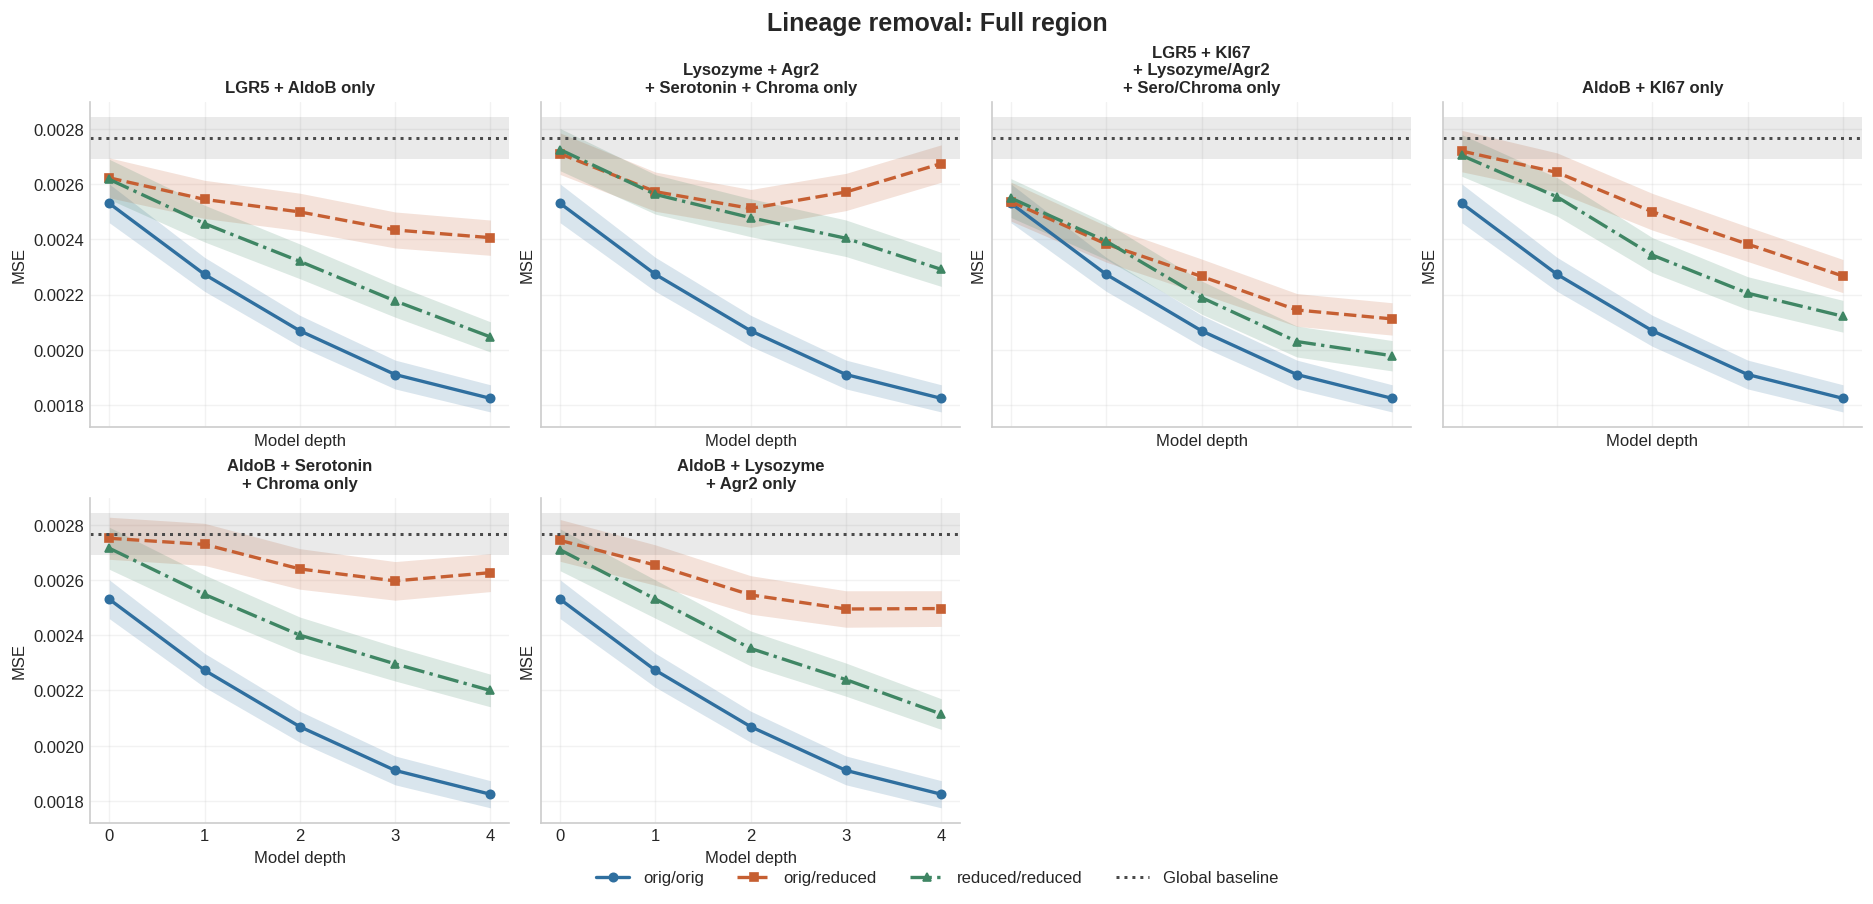

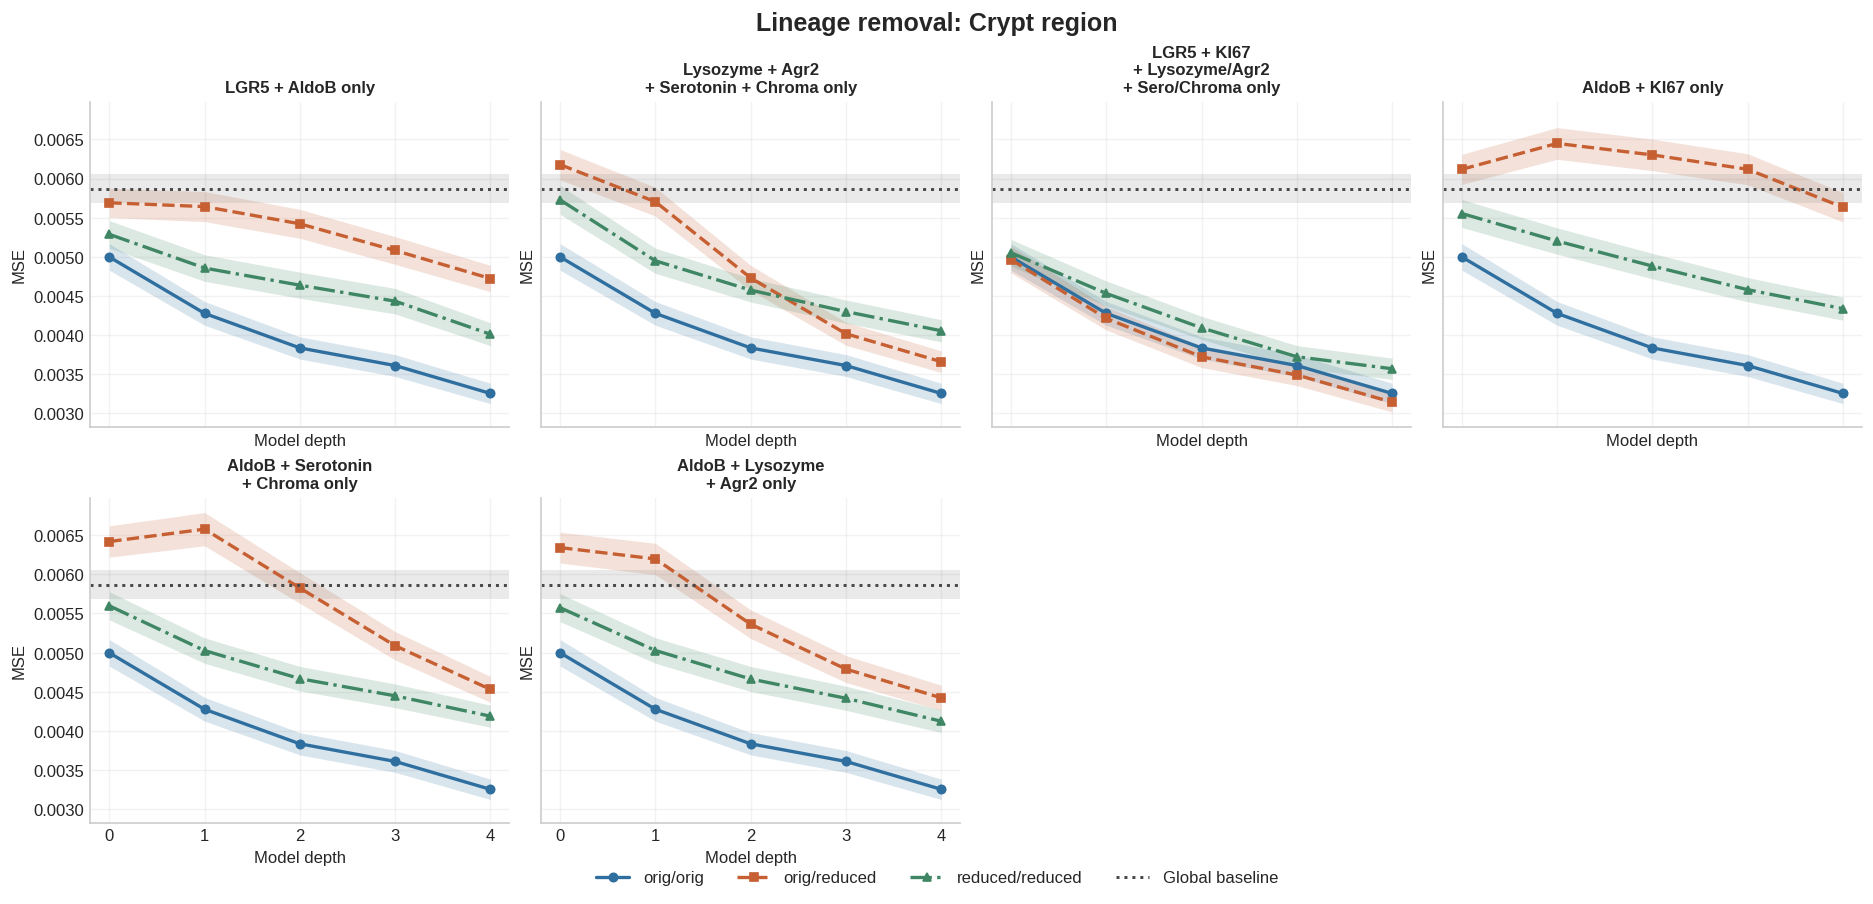

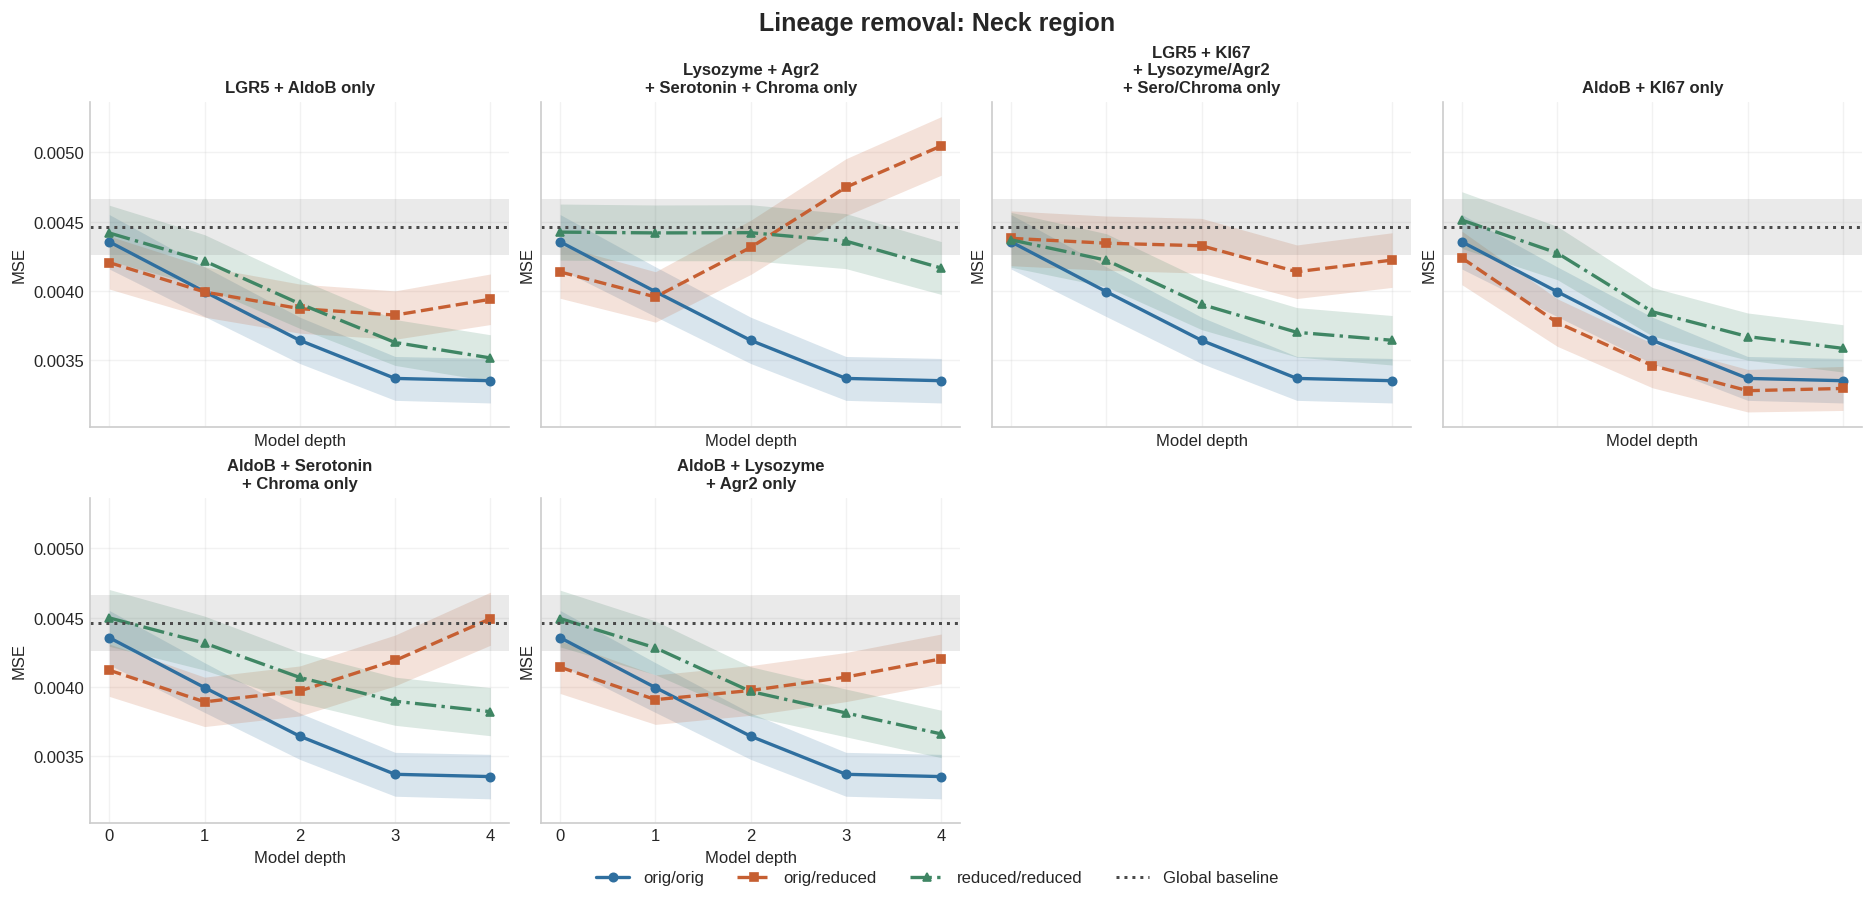

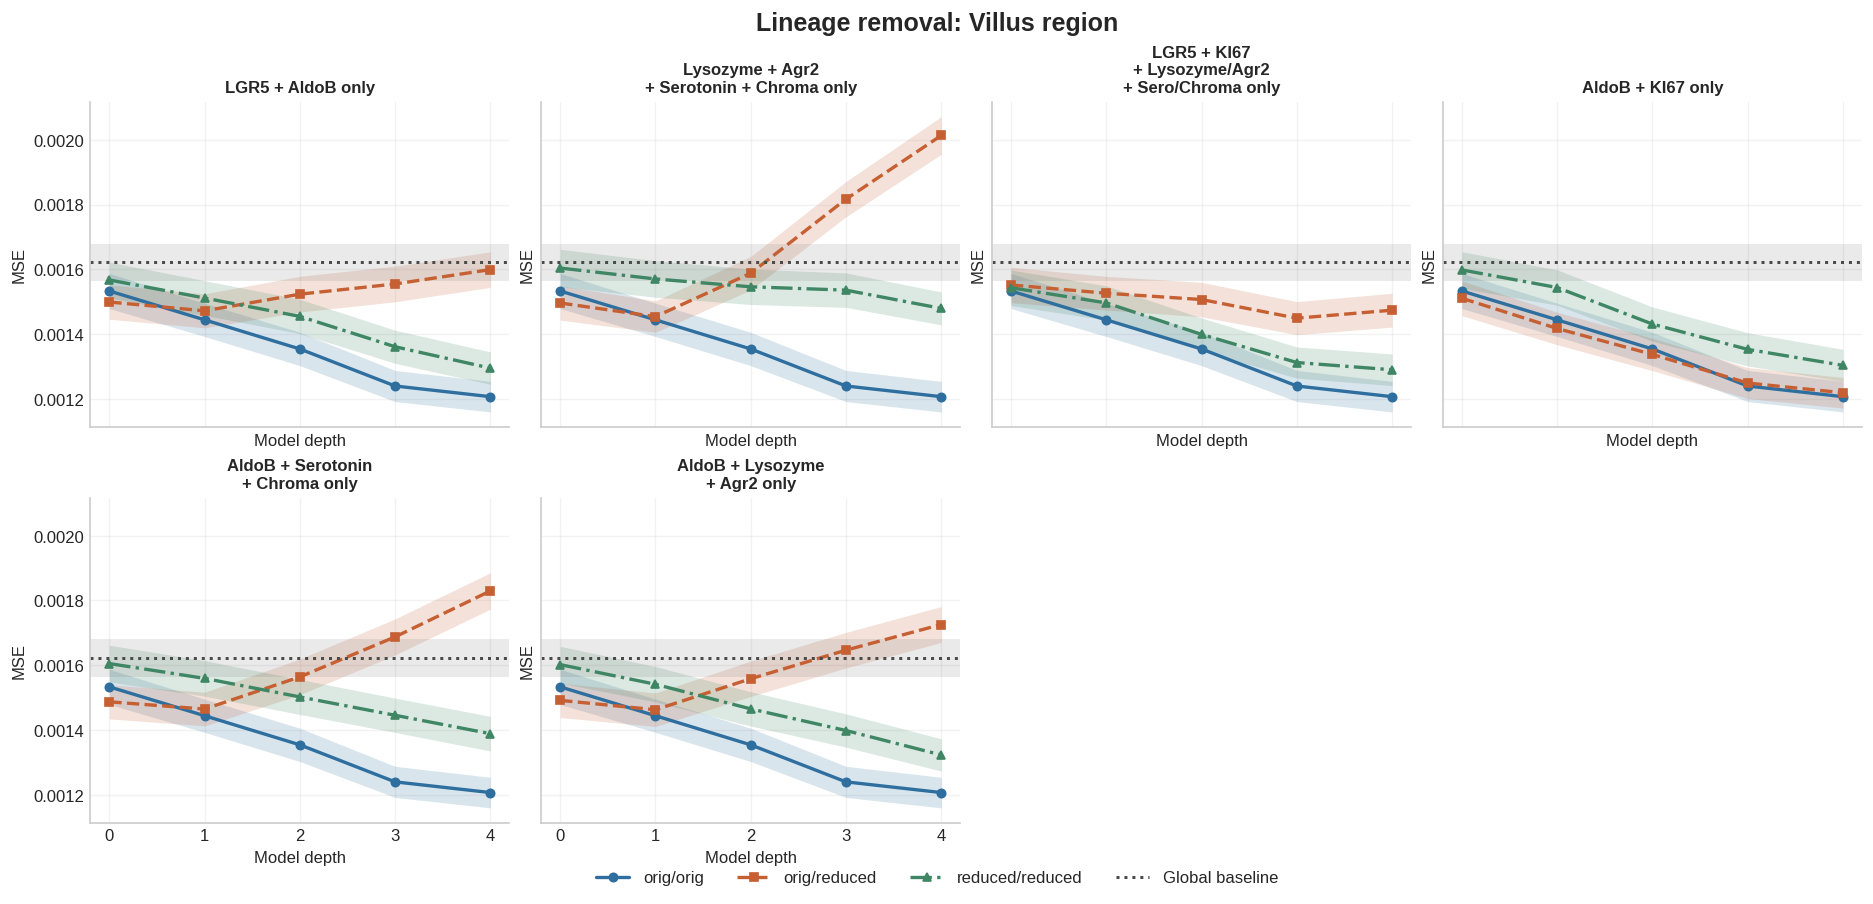

In [10]:
COMBO_ORDER = ["orig_orig", "orig_reduced", "reduced_reduced"]
COMBO_STYLE = {
    "orig_orig": {
        "label": "orig/orig",
        "color": "#2f6f9f",
        "marker": "o",
        "linestyle": "-",
    },
    "orig_reduced": {
        "label": "orig/reduced",
        "color": "#c65f32",
        "marker": "s",
        "linestyle": "--",
    },
    "reduced_reduced": {
        "label": "reduced/reduced",
        "color": "#3f8664",
        "marker": "^",
        "linestyle": "-.",
    },
}


def plot_region_mse(region):
    region_df = mse_summary_df[mse_summary_df["region"] == region]
    baseline_row = baseline_summary_df[
        baseline_summary_df["region"] == region
    ]
    if baseline_row.empty:
        raise ValueError(f"No global baseline result for region {region!r}.")
    baseline_mean = float(baseline_row.iloc[0]["mean_mse"])
    baseline_sem = float(baseline_row.iloc[0]["sem_mse"])

    n_panels = len(REMOVAL_SETS_RESOLVED)
    ncols = 4
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15.5, 3.6 * nrows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()
    legend_handles = []
    legend_labels = []

    for panel_idx, (ax, spec) in enumerate(zip(axes, REMOVAL_SETS_RESOLVED)):
        panel = region_df[region_df["removal_key"] == spec["key"]]
        for combo in COMBO_ORDER:
            style = COMBO_STYLE[combo]
            curve = (
                panel[panel["train_eval_key"] == combo]
                .sort_values("depth")
            )
            x = curve["depth"].to_numpy(dtype=float)
            y = curve["mean_mse"].to_numpy(dtype=float)
            sem = curve["sem_mse"].to_numpy(dtype=float)
            line, = ax.plot(
                x,
                y,
                color=style["color"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                linewidth=2.0,
                markersize=5,
                label=style["label"],
            )
            ax.fill_between(
                x,
                y - sem,
                y + sem,
                color=style["color"],
                alpha=0.18,
                linewidth=0,
            )
            if panel_idx == 0:
                legend_handles.append(line)
                legend_labels.append(style["label"])

        baseline_line = ax.axhline(
            baseline_mean,
            color="#4a4a4a",
            linestyle=":",
            linewidth=1.8,
            label="Global baseline",
        )
        ax.axhspan(
            baseline_mean - baseline_sem,
            baseline_mean + baseline_sem,
            color="#6b6b6b",
            alpha=0.14,
            linewidth=0,
        )
        ax.set_title(spec["label"], fontsize=10)
        ax.set_xticks(MODEL_DEPTHS)
        ax.set_xlabel("Model depth")
        ax.set_ylabel("MSE")
        ax.grid(alpha=0.25)

    for ax in axes[len(REMOVAL_SETS_RESOLVED):]:
        ax.set_visible(False)

    legend_handles.append(baseline_line)
    legend_labels.append("Global baseline")
    fig.legend(
        legend_handles,
        legend_labels,
        loc="outside lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.035),
    )
    fig.suptitle(
        f"Lineage removal: {region.capitalize()} region",
        fontsize=15,
        fontweight="bold",
    )
    save_figure(fig, f"lineage_removal_mse_{region}")
    return fig


region_figures = {
    region: plot_region_mse(region) for region in REGION_ORDER
}
plt.show()

## 8. Save Configuration

In [11]:
config = {
    "created_at": RUN_TIMESTAMP,
    "analysis_variant": ANALYSIS_VARIANT,
    "project_root": PROJECT_ROOT,
    "save_dir": SAVE_DIR,
    "dataset": {
        "name": DATASET_NAME,
        "target_indices": TARGET_INDICES,
        "target_index_for_analysis": TARGET_INDEX_FOR_ANALYSIS,
        "marker_names": marker_names,
    },
    "filtering": {
        "timepoint_filter_mode": TIMEPOINT_FILTER_MODE,
        "day3p5_timepoint": DAY3P5_TIMEPOINT,
        "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
        "fill_missing_complexity": FILL_MISSING_COMPLEXITY,
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
        "n_graphs_after_filtering": len(graphs),
    },
    "split": {
        "analysis_mode": ANALYSIS_MODE,
        "val_frac": VAL_FRAC,
        "n_folds": N_FOLDS,
        "split_seed": SPLIT_SEED,
        "folds_to_run": FOLDS_TO_RUN,
        "folds_completed": sorted(organoid_mse_df["fold"].unique().tolist()),
    },
    "model": {
        "class": "GINCurvature",
        "depths": MODEL_DEPTHS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
        "use_global_features": USE_GLOBAL_FEATURES,
        "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "predict_batch_size": PREDICT_BATCH_SIZE,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
        "save_model_checkpoints": SAVE_MODEL_CHECKPOINTS,
    },
    "regions": {
        "dcrypt_field": DCRYPT_FIELD,
        "crypt": f"d < {CRYPT_MAX}",
        "neck": f"{CRYPT_MAX} <= d <= {NECK_MAX}",
        "villus": f"d > {NECK_MAX} or non-finite",
        "crypt_shape_descriptors": {
            "source": "segmentation_path npz files",
            "nearest_crypt_assignment": "argmin d_crypts_graph per node",
            "crypt_constriction": "loaded from crypt_constrictions",
            "signed_neck_shape": (
                "C(s=NECK_CIRCUMFERENCE_DISTANCE) / "
                "max C(s < SIGNED_NECK_SHAPE_REFERENCE_MAX) - 1"
            ),
            "neck_circumference_distance": NECK_CIRCUMFERENCE_DISTANCE,
            "signed_neck_shape_reference_max": SIGNED_NECK_SHAPE_REFERENCE_MAX,
        },
    },
    "removal_sets": REMOVAL_SETS_RESOLVED,
    "evaluation": {
        "combinations": {
            "orig_orig": "original train / original validation",
            "orig_reduced": "original train / reduced validation",
            "reduced_reduced": "reduced train / reduced validation",
        },
        "aggregation_unit": "organoid",
        "uncertainty": "standard error across organoid-level MSE values",
        "baseline": "one GlobalFeatureMLP per fold, reused across removal panels",
        "crypt_shape_tables": {
            "organoid_level_mse": (
                "contains regional summaries of nearest crypt shape descriptors"
            ),
            "crypt_neck_shape_assignments": (
                "cell-level nearest-crypt shape assignments for crypt and neck nodes"
            ),
        },
    },
}

with open(SAVE_DIR / "settings.json", "w") as handle:
    json.dump(jsonable(config), handle, indent=2)

print(f"Saved figures, tables, and settings to {SAVE_DIR}")

Saved figures, tables, and settings to /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/lineage_removal/marker_panel_isolation_folded_depths-0-1-2-3-4_20260723_174336
